In [2]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (541909, 8)

Column names:
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
df = df.dropna(subset=['CustomerID', 'Description'])

print("Shape after removing missing values:", df.shape)

Shape after removing missing values: (406829, 8)


In [5]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5225


### Observation


The dataset contains 5,225 duplicate rows. These duplicate records may affect the accuracy of the analysis. 
Therefore, duplicate rows should be removed before further analysis.

In [6]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (401604, 8)


In [7]:
# Calculate total amount for each transaction
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Set reference date
reference_date = df['InvoiceDate'].max()

# Create RFM features
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          2      0.00
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40


### Observation



RFM analysis has been performed to understand customer purchasing behaviour. 
The Recency, Frequency, and Monetary features represent how recently customers purchased, how frequently they purchased, 
and how much they spent.
These three behavioural features will be used for customer segmentation.

In [8]:
# Descriptive statistics for RFM features
print("RFM Descriptive Statistics:")
print(rfm.describe())

# Average purchase value
average_purchase_value = df['TotalAmount'].sum() / df['InvoiceNo'].nunique()

print("\nAverage Purchase Value:", round(average_purchase_value, 2))

# Average purchase frequency
average_purchase_frequency = rfm['Frequency'].mean()

print("Average Purchase Frequency:", round(average_purchase_frequency, 2))

# Average customer value
average_customer_value = rfm['Monetary'].mean()

print("Average Customer Value:", round(average_customer_value, 2))

RFM Descriptive Statistics:
           Recency    Frequency       Monetary
count  4372.000000  4372.000000    4372.000000
mean     91.047118     5.075480    1893.531433
std     100.765435     9.338754    8218.696204
min       0.000000     1.000000   -4287.630000
25%      16.000000     1.000000     291.795000
50%      49.000000     3.000000     644.070000
75%     142.000000     5.000000    1608.335000
max     373.000000   248.000000  279489.020000

Average Purchase Value: 373.07
Average Purchase Frequency: 5.08
Average Customer Value: 1893.53


### Observation


The RFM descriptive statistics show that the dataset contains 4,372 customers. 
The average recency is 91.05 days, meaning customers purchased approximately 91 days before the reference date on average.
The average purchase frequency is 5.08 transactions per customer, while the average customer value is 1,893.53. 
The large variation in Monetary values shows that customers have different spending behaviours,
which makes RFM-based clustering useful for segmentation.

In [9]:
# Select RFM features for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

print("Features selected for clustering:")
print(rfm_features.head())

print("\nShape of selected features:", rfm_features.shape)

Features selected for clustering:
            Recency  Frequency  Monetary
CustomerID                              
12346.0         325          2      0.00
12347.0           1          7   4310.00
12348.0          74          4   1797.24
12349.0          18          1   1757.55
12350.0         309          1    334.40

Shape of selected features: (4372, 3)


### Observation



Recency, Frequency, and Monetary are selected as the key behavioural features for customer segmentation.
These three features represent how recently customers purchased, how frequently they purchased, and how much they spent. 
The selected dataset contains 4,372 customers and 3 features, which will be used for clustering.

In [10]:
from sklearn.preprocessing import StandardScaler

# Standardize RFM features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("Standardized RFM data:")
print(rfm_scaled[:5])

print("\nShape of standardized data:", rfm_scaled.shape)

Standardized RFM data:
[[ 2.32202285 -0.32936215 -0.23041952]
 [-0.89373323  0.20610242  0.29405454]
 [-0.1691956  -0.11517632 -0.01171748]
 [-0.72500529 -0.43645506 -0.01654727]
 [ 2.16322008 -0.43645506 -0.18972715]]

Shape of standardized data: (4372, 3)


### Observation


The RFM features have been standardized using StandardScaler. 
This puts Recency, Frequency, and Monetary on a comparable scale so that no single feature dominates the clustering process.
The standardized dataset contains 4,372 customers and 3 features.

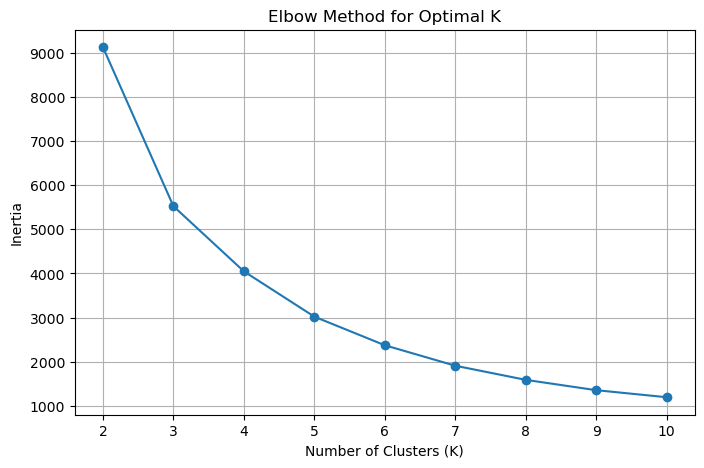

In [12]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Calculate inertia for different numbers of clusters
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### Observation




The Elbow Method was used to determine the optimal number of clusters. 
The inertia decreases as the number of clusters increases, with a noticeable reduction in the rate of decrease
around K = 4. Therefore, 4 clusters are selected for the K-Means customer segmentation analysis.

In [14]:
# Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Cluster labels assigned successfully.")

print("\nCluster distribution:")
print(rfm['Cluster'].value_counts().sort_index())

Cluster labels assigned successfully.

Cluster distribution:
Cluster
0    3169
1    1087
2       6
3     110
Name: count, dtype: int64


### Observation



K-Means clustering was successfully applied using 4 clusters.
The 4,372 customers were assigned to Cluster 0, Cluster 1, Cluster 2, and Cluster 3. 
The cluster sizes are different, indicating variations in customer purchasing behaviour. 
These clusters will be visualised and profiled to understand the characteristics of each customer segment.

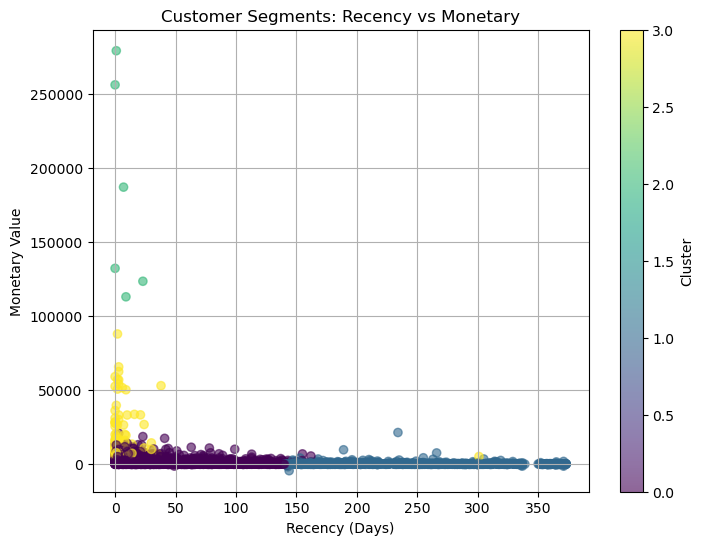

In [15]:
# Scatter plot: Recency vs Monetary
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm['Recency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Recency (Days)')
plt.ylabel('Monetary Value')
plt.title('Customer Segments: Recency vs Monetary')
plt.colorbar(label='Cluster')
plt.grid(True)

plt.show()

### Observation


The scatter plot shows the distribution of customers across the four clusters based on Recency and Monetary value. 
The clusters show different purchasing patterns, with customers separated according to their recent purchase activity and 
spending behaviour. This visualization helps in understanding the differences between customer segments.

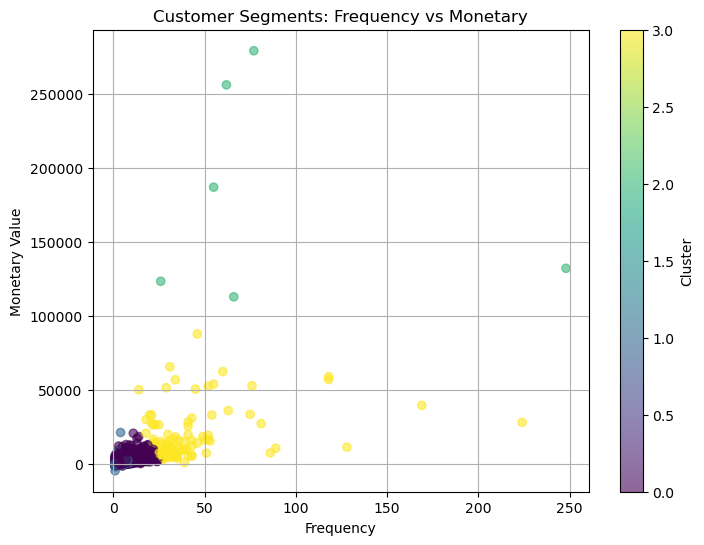

In [16]:
# Scatter plot: Frequency vs Monetary
plt.figure(figsize=(8, 6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    cmap='viridis',
    alpha=0.6
)

plt.xlabel('Frequency')
plt.ylabel('Monetary Value')
plt.title('Customer Segments: Frequency vs Monetary')
plt.colorbar(label='Cluster')
plt.grid(True)

plt.show()

### Observation



The scatter plot shows the distribution of customers across the four clusters based on Frequency and Monetary value.
Customers with different purchase frequencies and spending amounts are grouped into separate clusters. 
This visualization helps to understand how frequently customers purchase and how much they spend.

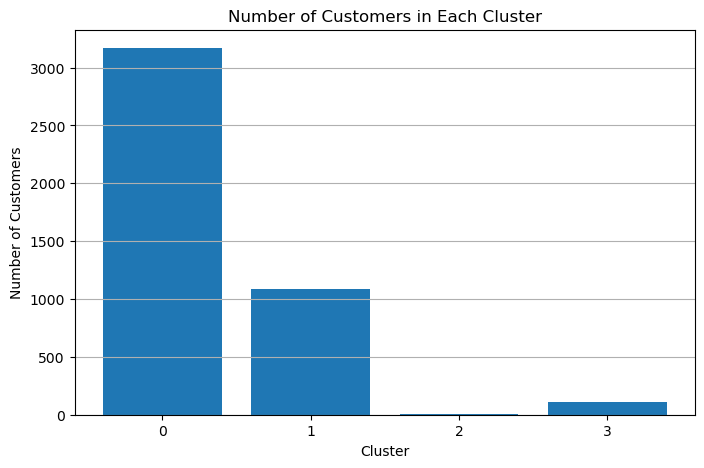

In [17]:
# Bar chart: Number of customers in each cluster
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')
plt.grid(axis='y')

plt.show()

### Observation


The bar chart shows the number of customers present in each cluster.
Cluster 0 contains the highest number of customers, followed by Cluster 1 and Cluster 3, while Cluster 2 contains very few customers.
This shows that the customer base is unevenly distributed across the four segments.

In [20]:
# Create cluster profile using mean RFM values
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2)

# Add number of customers in each cluster
cluster_profile['CustomerCount'] = rfm['Cluster'].value_counts().sort_index()

print("Cluster Profile:")
print(cluster_profile)

Cluster Profile:
         Recency  Frequency   Monetary  CustomerCount
Cluster                                              
0          40.61       4.80    1472.65           3169
1         246.95       1.81     451.80           1087
2           6.67      89.00  182108.08              6
3           8.18      40.67   18435.66            110


## Insights and Marketing Actions


### Cluster 0 – Regular Customers
These customers have moderate recency, frequency, and monetary values. They show regular purchasing behaviour.

**Marketing Action:**  
Offer personalized product recommendations, loyalty rewards, and occasional discounts to encourage repeat purchases.

### Cluster 1 – Inactive / Low-Activity Customers
These customers have high recency, low frequency, and low monetary value.
They have not purchased recently and show limited purchasing activity.

**Marketing Action:**  
Use re-engagement campaigns, special offers, and reminder emails to encourage them to return.

### Cluster 2 – High-Value Frequent Customers
These customers have very low recency, very high frequency, and extremely high monetary value. 
They represent a small group with very strong purchasing activity.

**Marketing Action:**  
Provide loyalty benefits, personalized offers, premium services, and exclusive product access to maintain their engagement.

### Cluster 3 – Frequent High-Spending Customers
These customers have very low recency, high frequency, and high monetary value. 
They purchase frequently and spend significantly.

**Marketing Action:**  
Encourage continued purchases through loyalty programs, personalized recommendations, 
early access to new products, and targeted offers.

### Overall Insight
The RFM-based K-Means clustering successfully divided 4,372 customers into four distinct segments based on their purchasing behaviour.
These segments can help an e-commerce company design targeted marketing strategies
instead of using the same approach for all customers.